In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("smartcart_customers.csv")

In [3]:
data.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
1179,5735,1991,Master,Single,90638.0,0,0,13-02-2014,29,1156,...,94,144,96,1,3,4,10,1,0,0
215,1584,1977,Graduation,Married,41443.0,1,0,01-04-2014,79,171,...,25,19,89,6,8,1,5,8,0,0
1725,2634,1979,Master,Single,16653.0,1,0,18-04-2014,10,5,...,15,4,7,3,2,1,3,6,0,1
65,8082,1971,Graduation,Married,25721.0,1,0,21-05-2013,75,1,...,3,6,15,1,1,1,2,7,0,1
153,92,1988,Graduation,Alone,34176.0,1,0,12-05-2014,12,5,...,19,14,20,4,3,0,4,6,0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
data["Year_Birth"].dtype

dtype('int64')

In [6]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## 1. Handle Missing Values

In [7]:
data["Income"] = data["Income"].fillna(data["Income"].median())

In [8]:
data.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## 2. Feature Engineering

In [9]:
# Birth-Date -> Age
data["Age"] = 2026-data["Year_Birth"]

In [10]:
data.sample()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
2111,1008,1981,PhD,Together,44953.0,0,0,21-12-2012,31,728,...,8,124,1,7,3,13,6,0,0,45


In [11]:
# Customer-Joining-Date -> Customer Tenure Days

data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"],dayfirst=True)

reference_date = data["Dt_Customer"].max()

data["Customer_Tenure_Days"] = (reference_date - data["Dt_Customer"]).dt.days

In [12]:
# Total Spending :

data["Total_Spending"] = (data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] 
                        + data["MntFishProducts"] + data["MntSweetProducts"]+ data["MntGoldProds"])

In [13]:
# Total Children :

data["Total_Children"] = (data["Kidhome"] + data["Teenhome"])

In [14]:
# Education :

data["Education"].value_counts()

data["Education"] = data["Education"].replace({
    "Graduation" : "Graduate",
    "PhD" : "Postgraduate","Master" : "Postgraduate",
    "2n Cycle" : "Undergraduate","Basic" : "Undergraduate"
})

In [15]:
# Marital-Status :

data["Marital_Status"].value_counts()

data["Living_With"] = data["Marital_Status"].replace({
    "Married" : "Partner","Together" : "Partner",
    "Divorced" : "Single","Widow" : "Single","Alone" : "Single","Absurd" : "Single","YOLO" : "Single"
})

## 3. Drop Columns

In [16]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='object')

In [17]:
drop_cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome",
             "MntMeatProducts","Dt_Customer","MntWines","MntFruits","MntMeatProducts",
             "MntFishProducts","MntSweetProducts","MntGoldProds"]

data_cleaned = data.drop(drop_cols,axis=1)

In [18]:
data_cleaned.shape

(2240, 15)

## 4. Outliers

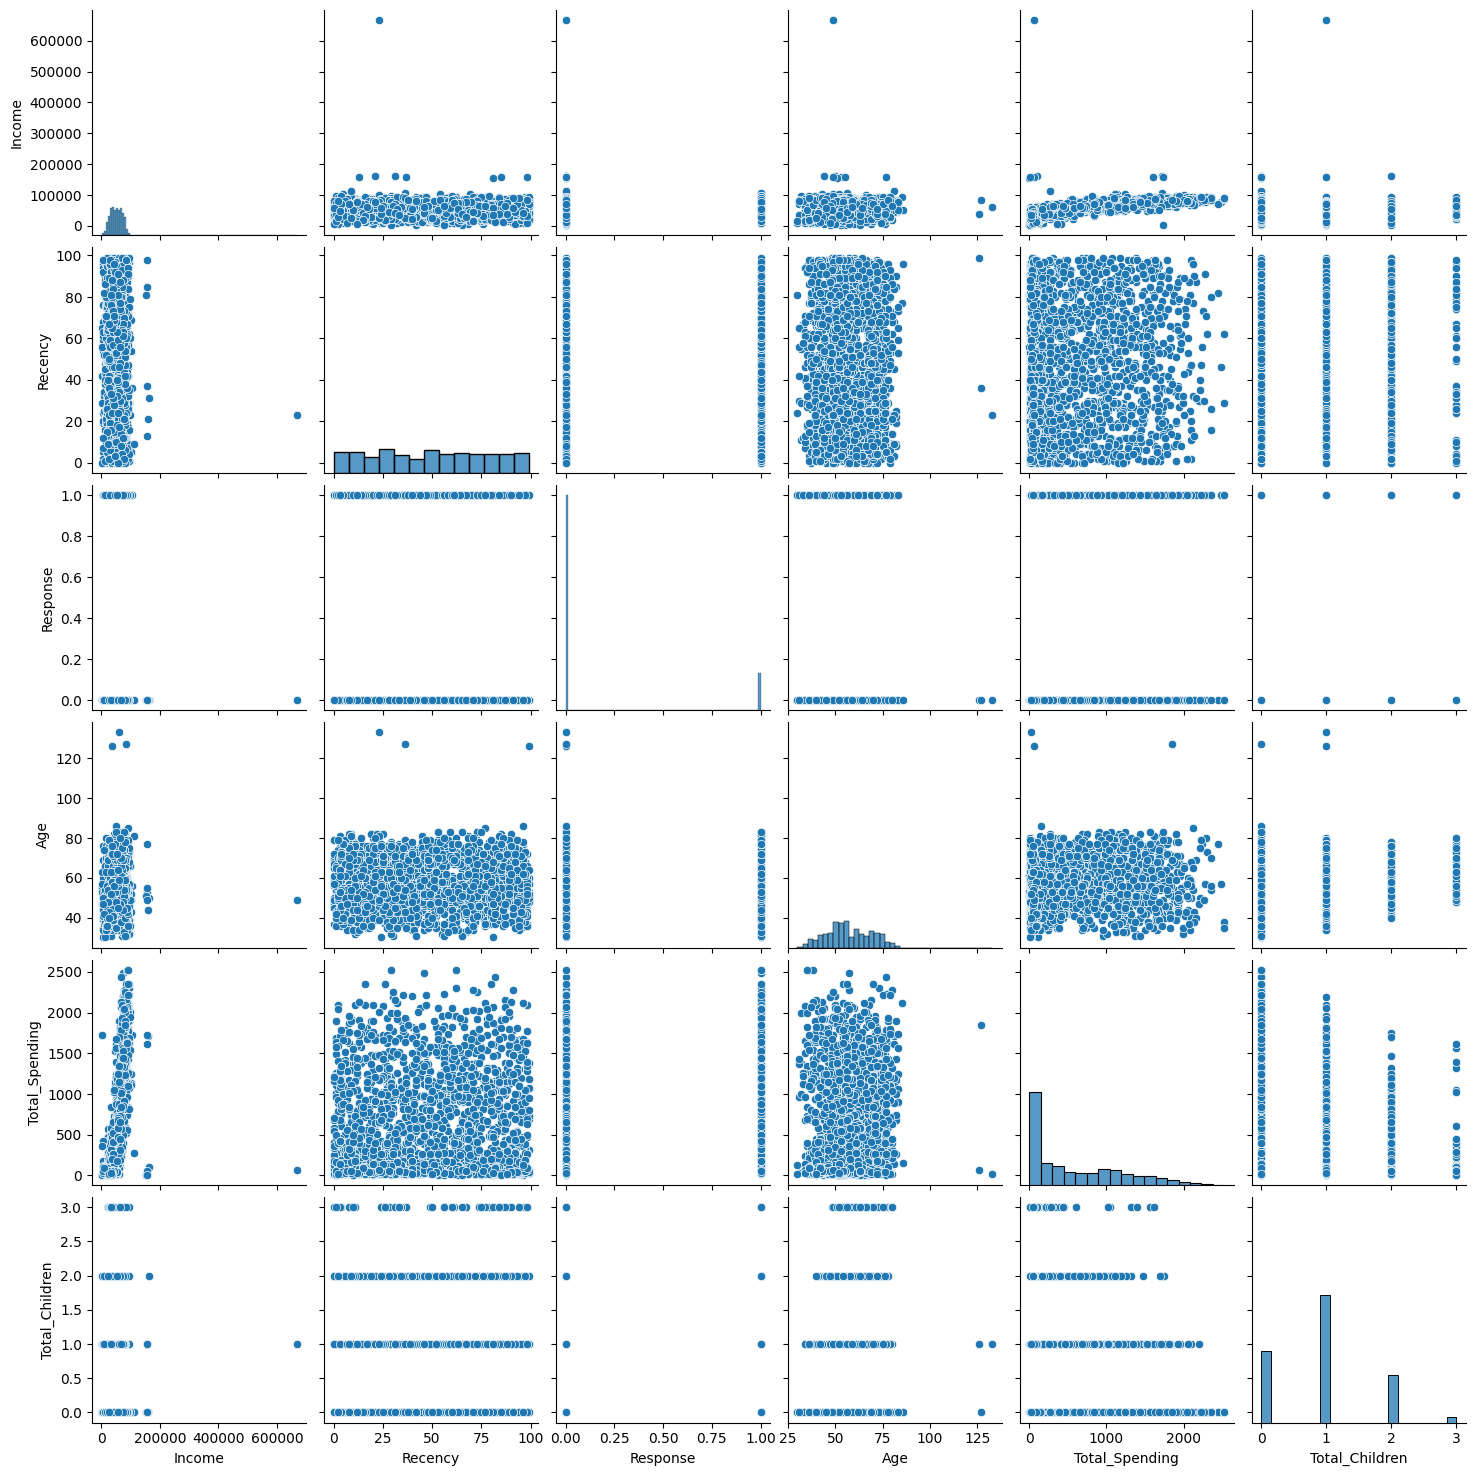

In [19]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]

# Relative plots of some features - (Pair Plots)

sns.pairplot(data_cleaned[cols])

In [20]:
# Remove the outliers :

print("Data size with outliers : ",len(data_cleaned))

data_cleaned = data_cleaned[(data_cleaned["Age"] < 90)]
data_cleaned = data_cleaned[(data_cleaned["Income"] < 600000)]

print("Data size without outliers : ",len(data_cleaned))

Data size with outliers :  2240
Data size without outliers :  2236


# Heatmap

In [21]:
corr = data_cleaned.corr(numeric_only=True)

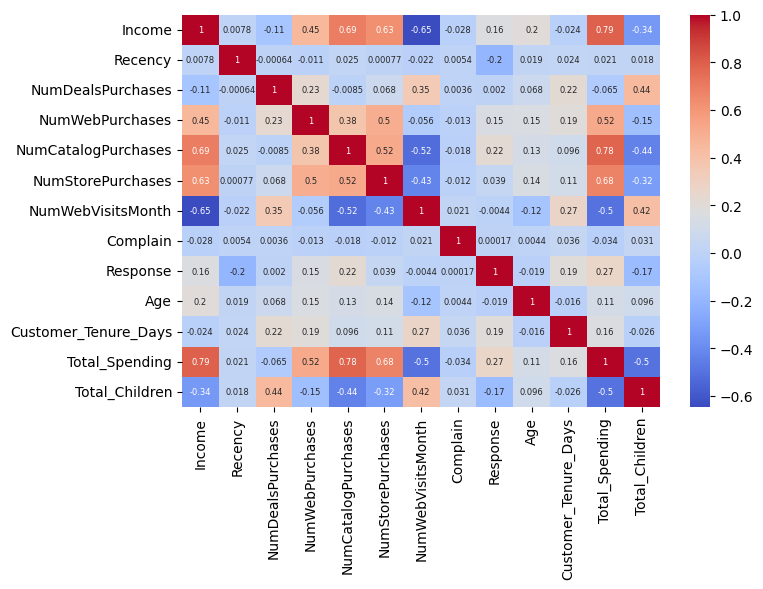

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)
plt.tight_layout()

# Encoding

In [23]:
from sklearn.preprocessing import OneHotEncoder

In [24]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(data_cleaned[cat_cols])

In [25]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=data_cleaned.index)

In [26]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Partner,Living_With_Single
0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,1.0,0.0


In [27]:
data_encoded = pd.concat([data_cleaned.drop(columns=cat_cols),enc_df],axis=1)

# Scaling

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
X = data_encoded.copy()

In [30]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualization

In [31]:
X_scaled.shape

(2236, 18)

In [32]:
from sklearn.decomposition import PCA

In [33]:
# 2D :

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.23163158 0.11385454]


<Axes: >

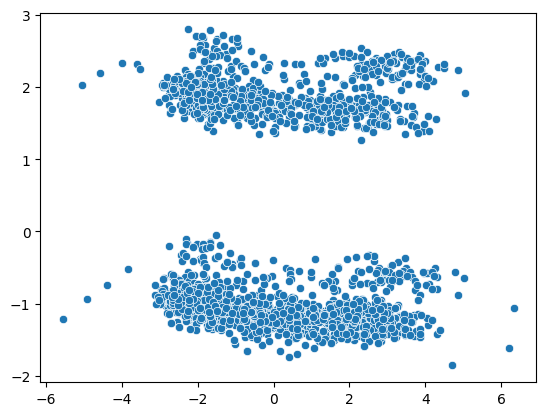

In [34]:
# Plot:

sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1])

In [35]:
# 3D :

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.23163158 0.11385454 0.10405815]


Text(0.5, 0.92, '3d - Visualization')

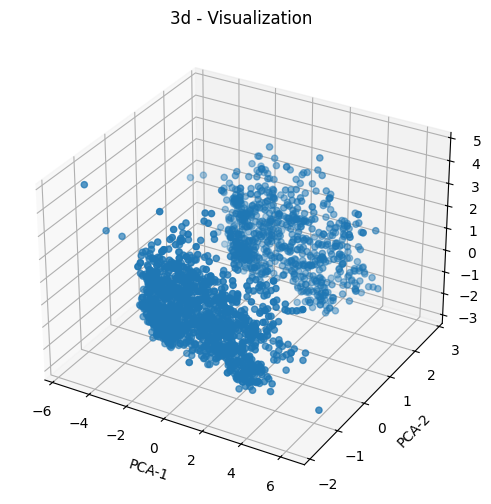

In [36]:
# Plot :

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA-1")
ax.set_ylabel("PCA-2")
ax.set_zlabel("PCA-3")
ax.set_title("3d - Visualization")

## Analyze the K Value

### 1. ELbow Method :

In [37]:
from sklearn.cluster import KMeans

from kneed import KneeLocator

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

Text(0.5, 1.0, 'Elbow Method')

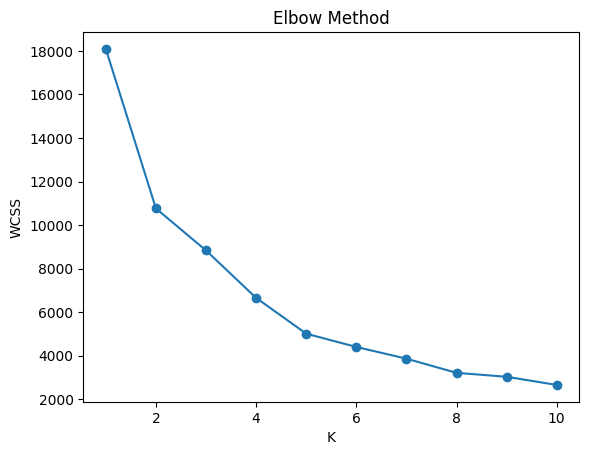

In [38]:
# Plot :

plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")

In [39]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow
print(f"Optimal K : {optimal_k}")

Optimal K : 4


### 2. Silhouette Score

In [40]:
from sklearn.metrics import silhouette_score

sh_score = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    sh_score.append(silhouette_score(X_pca,labels))

Text(0, 0.5, 'Silhouette Score')

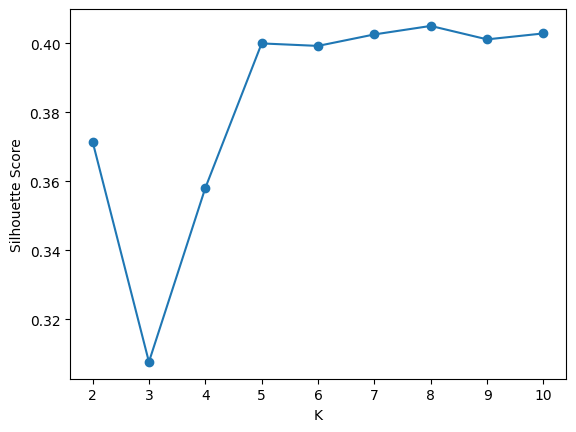

In [41]:
# Plot :

plt.plot(range(2,11),sh_score,marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")

Text(0, 0.5, 'Silhouette Score')

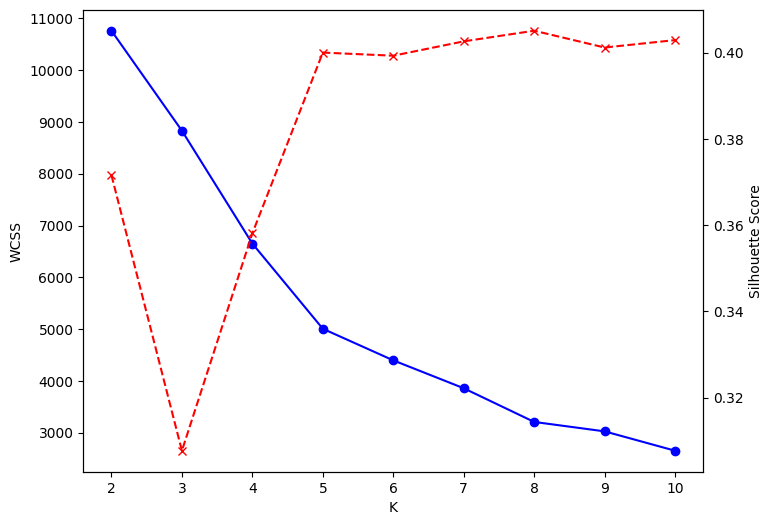

In [42]:
# Combined Plot :

k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[1:],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range,sh_score,marker="x",color="red",linestyle="--")
ax2.set_ylabel("Silhouette Score")

# Clustering :

## 1. KMeans :

In [43]:
kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

Text(0.5, 0.92, 'Clustering 3d Visualization')

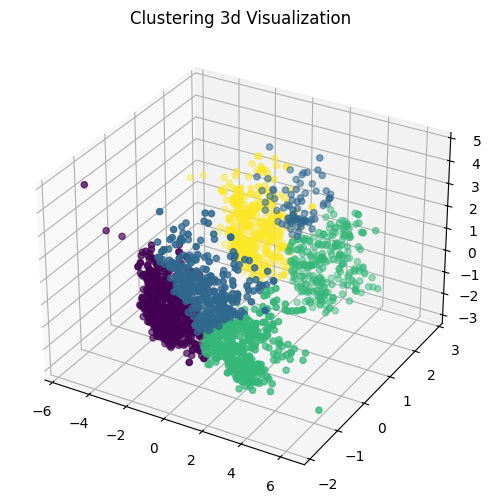

In [44]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

ax.set_title("Clustering 3d Visualization")

## 2. Agglomerative Clustering

In [45]:
from sklearn.cluster import AgglomerativeClustering

In [46]:
agg_cls = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_cls.fit_predict(X_pca)

Text(0.5, 0.92, 'Clustering 3d Visualization')

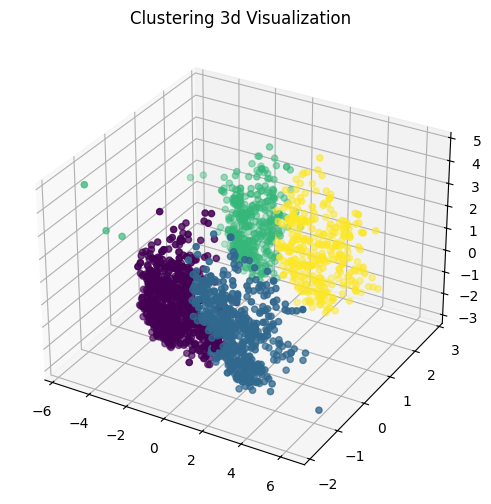

In [47]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

ax.set_title("Clustering 3d Visualization")

# Characterization of Clusters

In [49]:
data_cleaned["Labels"] = labels_agg

In [50]:
data_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With,Labels
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Single,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Single,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0


<Axes: xlabel='Labels', ylabel='count'>

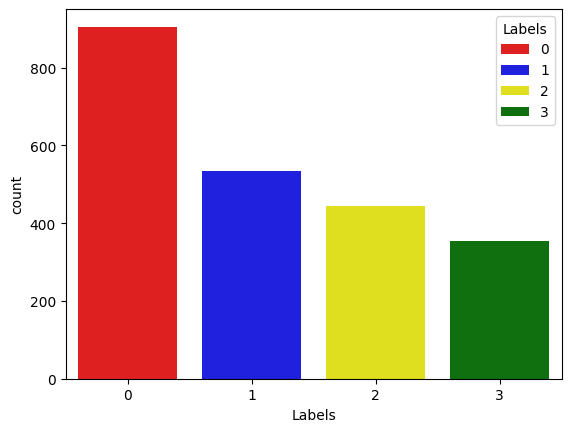

In [53]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=data_cleaned["Labels"], palette=pal,hue=data_cleaned["Labels"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

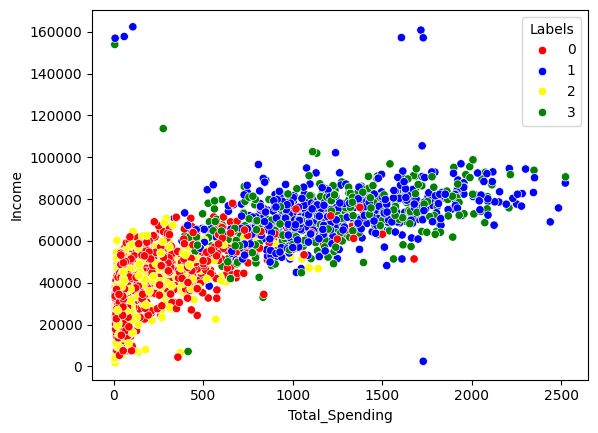

In [54]:
sns.scatterplot(x=data_cleaned["Total_Spending"], y=data_cleaned["Income"], hue=data_cleaned["Labels"], palette=pal)

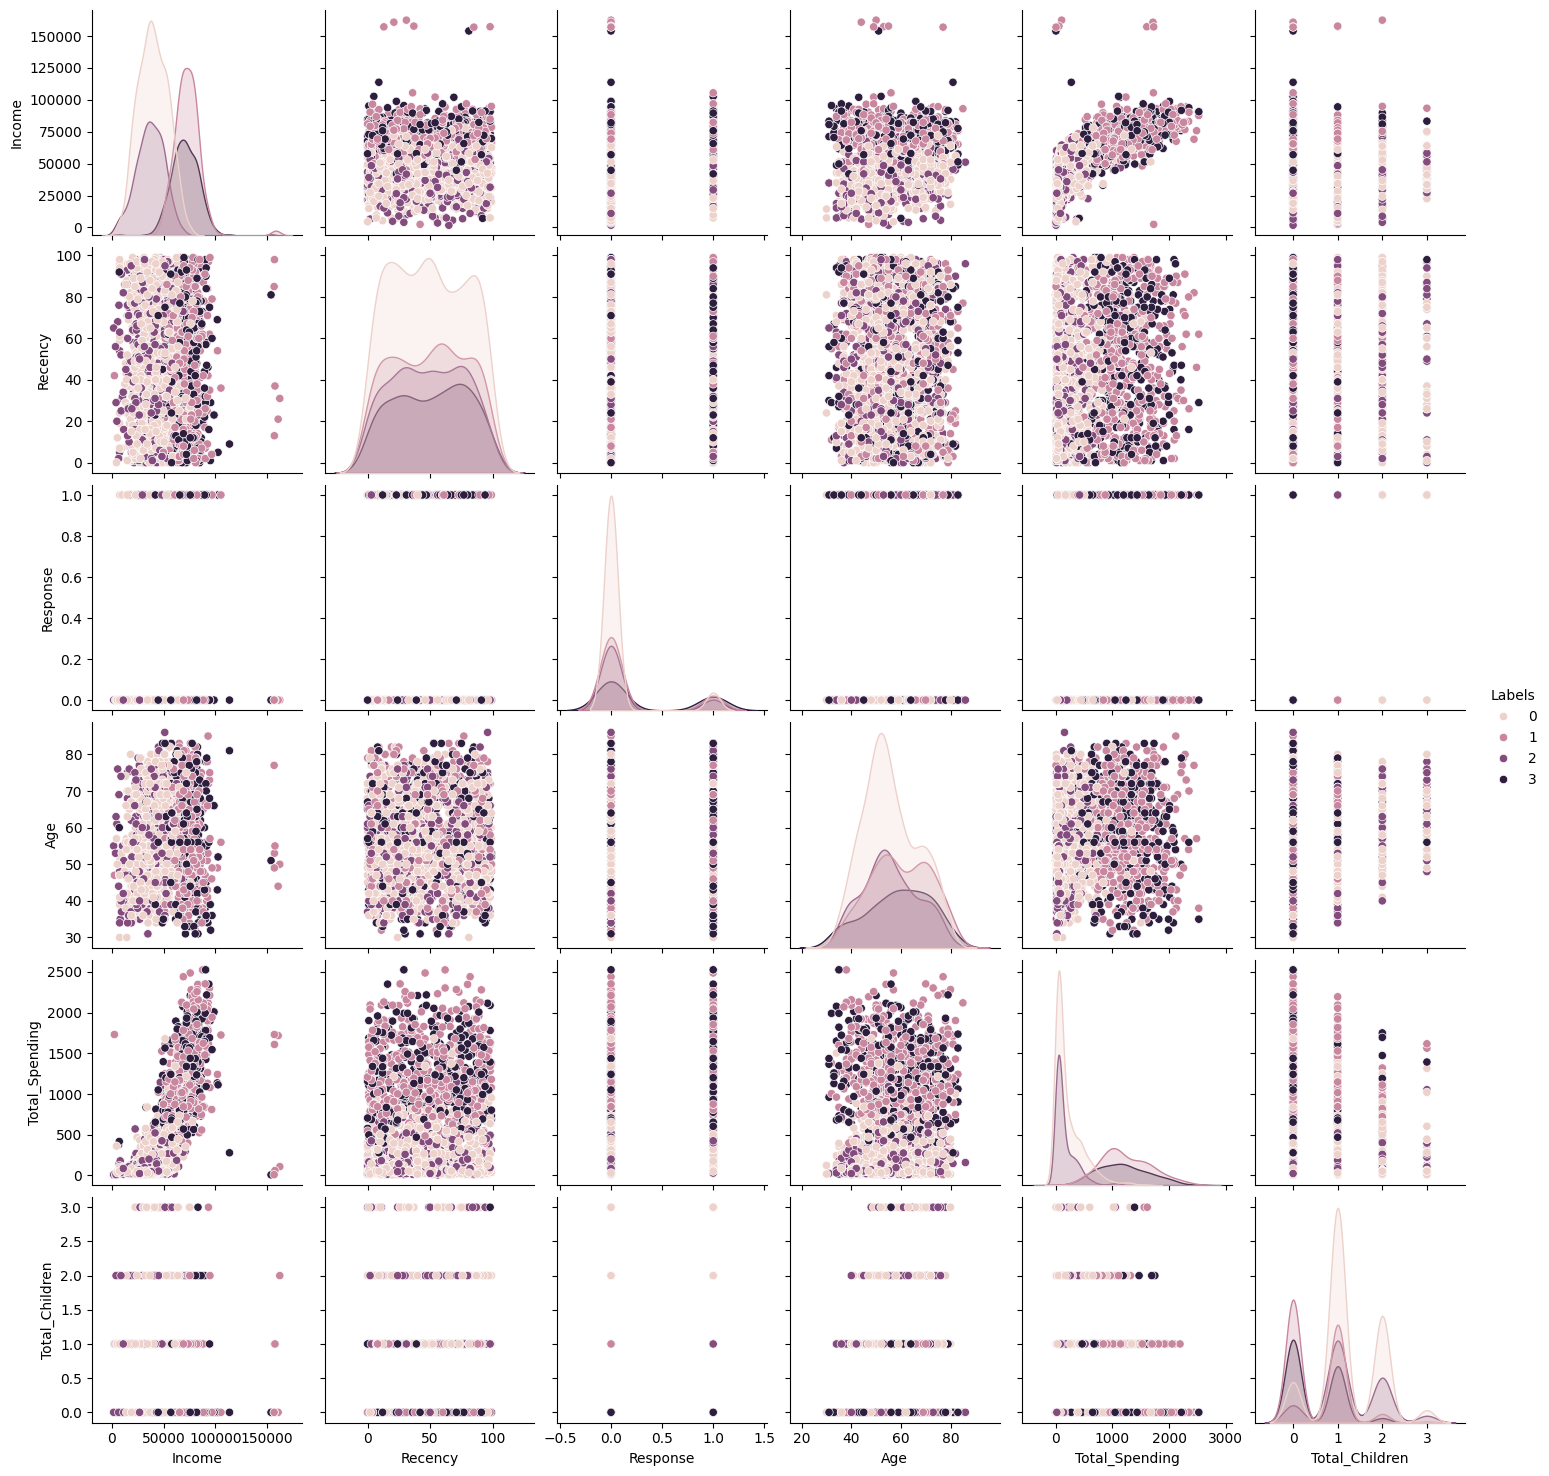

In [58]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]

# Relative plots of some features - (Pair Plots)

sns.pairplot(data_cleaned[cols+["Labels"]], hue="Labels")